<a href="https://colab.research.google.com/github/AliceFranca0/tcc-deteccao-fake-news-ptbr/blob/main/Fase4_Agencias_FactChecking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 4 — Agências de Fact-Checking de Origem

O FakeRecogna foi construído a partir de verificações publicadas por agências brasileiras de fact-checking. Essa informação não consta em coluna própria, mas pode ser recuperada do domínio e do caminho da URL de cada registro.

Esta fase estabelece a ligação entre o corpus e o ecossistema de fact-checking discutido no referencial teórico do artigo.

## 1. Ambiente

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/TCC"

import os
os.makedirs(f"{BASE}/dados", exist_ok=True)
os.makedirs(f"{BASE}/figuras", exist_ok=True)
os.makedirs(f"{BASE}/modelos", exist_ok=True)

print("Pastas prontas em", BASE)

Mounted at /content/drive
Pastas prontas em /content/drive/MyDrive/TCC


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

CORAL = "#EF476F"   # Fake
AZUL = "#118AB2"    # Real

mpl.rcParams.update({
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": "#073B4C",
    "axes.labelsize": 10.5,
    "axes.labelweight": "bold",
    "axes.edgecolor": "#999999",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.7,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

In [3]:
import pandas as pd

df = pd.read_csv(f"{BASE}/dados/fakerecogna_bruto.csv")
df = df.dropna(subset=["Noticia", "Classe", "Categoria", "URL"]).reset_index(drop=True)
df["Classe"] = df["Classe"].astype(int)
print(f"{len(df)} registros")

11902 registros


## 2. Identificação da agência de origem

A detecção considera o **caminho** da URL, não apenas o domínio: Projeto Comprova e UOL Confere publicam sob o domínio da UOL (`/comprova/` e `/confere/`), e seriam agregados incorretamente se apenas o domínio fosse analisado.

In [4]:
def identificar_fonte(url):
    if pd.isna(url):
        return "Não identificado"
    url = str(url).lower()

    # Dependem do caminho da URL, não só do domínio
    if "projetocomprova" in url or "/comprova/" in url:
        return "Projeto Comprova"
    if "/confere/" in url:
        return "UOL Confere"

    # Agências de fact-checking
    if "boatos.org" in url:
        return "Boatos.org"
    if "aosfatos" in url:
        return "Aos Fatos"
    if "e-farsas" in url:
        return "E-farsas"
    if "checamos.afp" in url or "afp-brasil" in url:
        return "AFP Checamos"
    if "fato-ou-fake" in url:
        return "Fato ou Fake (G1)"
    if "estadao" in url and "verifica" in url:
        return "Estadão Verifica"
    if "lupa" in url:
        return "Agência Lupa"

    # Veículos de notícias verdadeiras
    if "g1.globo.com" in url:
        return "G1"
    if "extra.globo.com" in url:
        return "Extra"
    if "gov.br" in url:
        return "Ministério da Saúde"
    if "uol.com.br" in url:
        return "UOL"

    return "Outra fonte (verificar)"

df["fonte"] = df["URL"].apply(identificar_fonte)
df.loc[df["Classe"] == 0, "fonte"].value_counts()

,count
fonte,
Boatos.org,2484
Fato ou Fake (G1),1184
E-farsas,804
Projeto Comprova,674
AFP Checamos,503
UOL Confere,284
UOL,18


In [5]:
nao_id = (df["fonte"] == "Outra fonte (verificar)").sum()
print(f"URLs não identificadas: {nao_id} ({nao_id/len(df)*100:.2f}%)")
if nao_id:
    print(df[df["fonte"] == "Outra fonte (verificar)"]["URL"].drop_duplicates().head(10).to_string(index=False))

URLs não identificadas: 0 (0.00%)


## 3. Cobertura das agências citadas no artigo

In [6]:
citadas = {"Aos Fatos", "Boatos.org", "Estadão Verifica",
            "Fato ou Fake (G1)", "Agência Lupa", "UOL Confere"}

contagem_fake = df.loc[df["Classe"] == 0, "fonte"].value_counts()
presentes = set(contagem_fake[contagem_fake >= 10].index)

print("Citadas no artigo COM presença relevante:", sorted(citadas & presentes))
print("Citadas no artigo com presença residual:", sorted(citadas - presentes))
print("No corpus mas não citadas:", sorted(presentes - citadas))

Citadas no artigo COM presença relevante: ['Boatos.org', 'Fato ou Fake (G1)', 'UOL Confere']
Citadas no artigo com presença residual: ['Agência Lupa', 'Aos Fatos', 'Estadão Verifica']
No corpus mas não citadas: ['AFP Checamos', 'E-farsas', 'Projeto Comprova', 'UOL']


## 4. Volume por agência

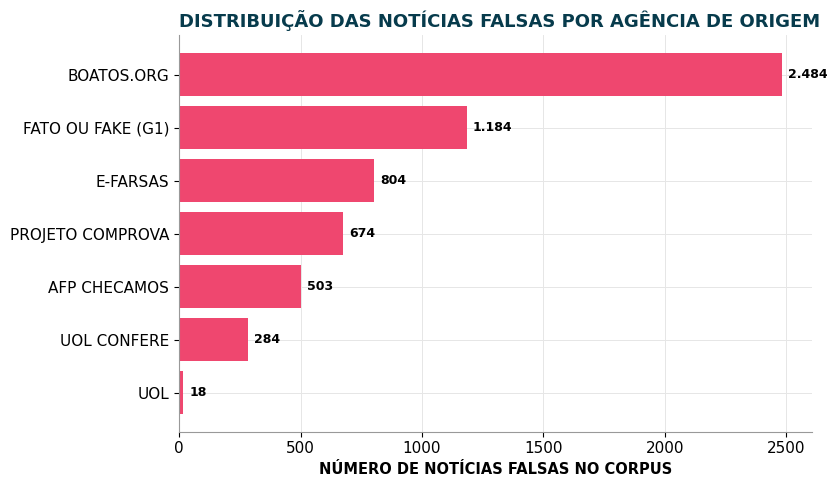

In [7]:
contagem = contagem_fake.drop(labels=["Não identificado"], errors="ignore")
contagem.index = [i.upper() for i in contagem.index]
contagem = contagem.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(contagem.index, contagem.values, color=CORAL)
for i, v in enumerate(contagem.values):
    ax.text(v + max(contagem.values) * 0.01, i, f"{v:,}".replace(",", "."),
            va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("NÚMERO DE NOTÍCIAS FALSAS NO CORPUS")
ax.set_title("DISTRIBUIÇÃO DAS NOTÍCIAS FALSAS POR AGÊNCIA DE ORIGEM", loc="left")
plt.tight_layout()
plt.savefig(f"{BASE}/figuras/figura_volume_por_agencia.png")
plt.show()

## 5. Checkpoint

In [8]:
df.to_csv(f"{BASE}/dados/fakerecogna_com_fonte.csv", index=False)
print("Salvo em", f"{BASE}/dados/fakerecogna_com_fonte.csv")

Salvo em /content/drive/MyDrive/TCC/dados/fakerecogna_com_fonte.csv
